# Timepix3 ToF Cluster Classification Pipeline

This notebook walks through every stage of the pipeline interactively.

| Stage | Module | Description |
|---|---|---|
| E | `synth.py` | Synthetic data generator (or load real data via `readtpx3`) |
| A | `tdc.py` | TDC diagnostics — measures beam period |
| B | `clustering.py` | Streaming open-cluster algorithm |
| C | `features.py` | Per-cluster scalar feature extraction |
| D | `tof.py` | Time-of-flight computation and folding |
| F | `labeling.py` | Mixture-fit labeling (K Gaussians + uniform background) |
| H | `baseline.py` | GBT baseline classifier |
| G | `diagnostics.py` | Contamination diagnostics and final reports |

> **Language note throughout:** labels refer to *folded-ToF bins*, not particle species.
> Species interpretation requires SME input.

## 0. Setup

In [1]:
import sys, pathlib
# Add src/ to the path so tpx3pipe is importable
repo_root = pathlib.Path(".").resolve()
src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110
%matplotlib inline

from tpx3pipe.io import load_config

cfg = load_config("config.yaml")
print("Config loaded.")
print(f"  Synth duration : {cfg['synth']['duration_s']} s")
print(f"  Period (config): {cfg['synth']['period_ns']} ns")
print(f"  Clustering Δt  : {cfg['clustering']['dt_ns']} ns")

Config loaded.
  Synth duration : 0.1 s
  Period (config): 1785.0 ns
  Clustering Δt  : 2000 ns


## Stage E — Data loading

**Synthetic mode (default):** generates pixel hits and TDC edges with known ground truth,
including wraparound contamination from slow particles whose true ToF exceeds one period.

**Real data mode:** set `tpx3.file` in `config.yaml` — the cell below switches automatically.

In [2]:
tpx3_cfg = cfg.get("tpx3", {})
tpx3_file = tpx3_cfg.get("file")

if tpx3_file:
    # ---- Real data via readtpx3.py ----------------------------------------
    from tpx3pipe.io import load_from_tpx3
    pixel_df, tdc_df = load_from_tpx3(
        tpx3_file,
        module_path=tpx3_cfg.get("module_path"),
        column_map=tpx3_cfg.get("column_map") or {},
    )
    truth_df = None
    print(f"Loaded REAL data: {len(pixel_df):,} pixels, {len(tdc_df):,} TDC edges")

else:
    # ---- Synthetic data ----------------------------------------------------
    from tpx3pipe.synth import generate
    pixel_df, tdc_df, truth_df = generate(cfg, seed=cfg["seed"])
    print(f"Generated SYNTHETIC data")
    print(f"  Pixel hits : {len(pixel_df):,}")
    print(f"  TDC edges  : {len(tdc_df):,}")
    print(f"  True clusters: {len(truth_df):,}")
    print(f"  Wrapped (true ToF > period): "
          f"{(truth_df['wrap_count'] > 0).sum()} "
          f"({100*(truth_df['wrap_count']>0).mean():.1f}%)")

Generated SYNTHETIC data
  Pixel hits : 37,921
  TDC edges  : 54,916
  True clusters: 6,567
  Wrapped (true ToF > period): 518 (7.9%)


In [3]:
# Quick look at the pixel dataframe
print("Pixel dataframe columns:", list(pixel_df.columns))
pixel_df.head()

Pixel dataframe columns: ['x_pix', 'y_pix', 'toa', 'ftoa', 'spidr_time', 'time_ns', 'tot']


,x_pix,y_pix,toa,ftoa,spidr_time,time_ns,tot
0,75,225,0,0,0,9.951581e+07,152
1,160,85,0,0,0,9.954257e+07,625
2,75,226,0,0,0,9.951584e+07,175
3,177,146,0,0,0,9.959633e+07,161
4,42,24,0,0,0,3.928629e+07,100


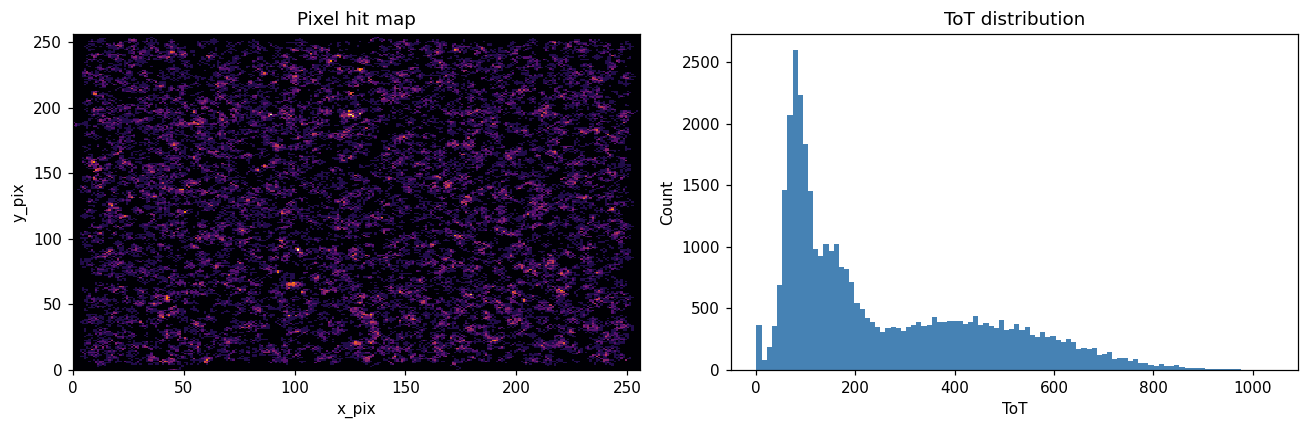

In [4]:
# Pixel hit map
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist2d(pixel_df["x_pix"], pixel_df["y_pix"],
               bins=[256, 256], range=[[0,256],[0,256]], cmap="inferno")
axes[0].set_xlabel("x_pix"); axes[0].set_ylabel("y_pix")
axes[0].set_title("Pixel hit map")

axes[1].hist(pixel_df["tot"], bins=100, color="steelblue")
axes[1].set_xlabel("ToT"); axes[1].set_ylabel("Count")
axes[1].set_title("ToT distribution")

plt.tight_layout()

## Stage A — TDC Diagnostics

Measures the beam-pulse period from consecutive TDC edge differences.
Everything downstream uses the **measured** period, not the config value.

In [5]:
import pathlib, json
from tpx3pipe.tdc import run_tdc_diagnostics

out_dir   = pathlib.Path(cfg["paths"]["artifacts"])
plots_dir = pathlib.Path(cfg["paths"]["plots"])
out_dir.mkdir(exist_ok=True)
plots_dir.mkdir(exist_ok=True)

tdc_report = run_tdc_diagnostics(tdc_df, cfg, out_dir, plots_dir)
period_ns  = tdc_report["measured_period_ns"]
print(f"\nMeasured period: {period_ns:.3f} ns")

=== TDC Diagnostics ===
  Measured period:          1785.009 ns
  Period spread (std):      256.471 ns
  Total edges:              54916
  Gaps with missed edges:   1085
  Estimated missing edges:  1108
  Fraction periods affected:0.0198
  Span discrepancy:         1977243.6 ns

Measured period: 1785.009 ns


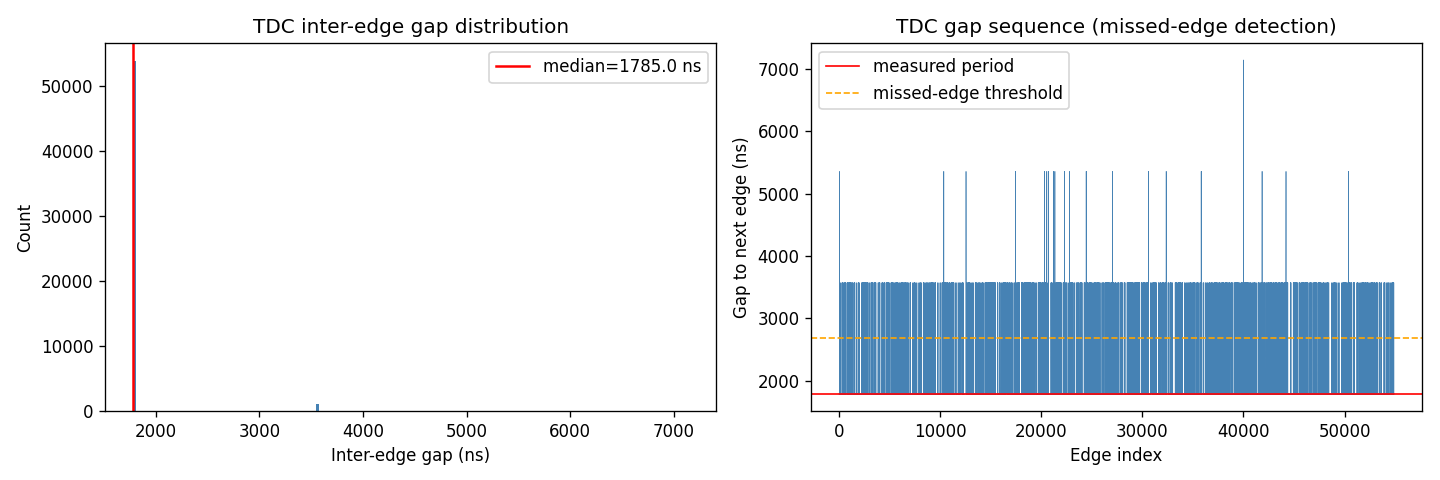

In [6]:
# Show the saved diagnostic plot inline
from IPython.display import Image
Image(plots_dir / "tdc_diagnostics.png")

In [7]:
# Full TDC report as a table
pd.Series(tdc_report).to_frame("value")

,value
measured_period_ns,1.785009e+03
period_spread_ns,2.564711e+02
n_edges,5.491600e+04
n_gaps_with_missed_edges,1.085000e+03
n_missing_edges_estimated,1.108000e+03
frac_periods_affected,1.977700e-02
total_span_ns,1.000010e+08
expected_span_ns,9.802378e+07
span_discrepancy_ns,1.977244e+06


## Stage B — Clustering

Streaming open-cluster algorithm (Meduna et al. 2019).
Pixels are joined if they are within **Δt ns** (temporal) and **8-connected** (spatial).
We sort by `time_ns` first, then close open clusters once the stream time passes
`cluster_max_time + Δt + safety_margin`.

In [8]:
from tpx3pipe.clustering import cluster_pixels

ccfg = cfg["clustering"]
clusters_df, cluster_pixels_df = cluster_pixels(
    pixel_df,
    dt_ns           = ccfg["dt_ns"],
    max_gap         = ccfg["max_gap"],
    time_criterion  = ccfg["time_criterion"],
    safety_margin_ns= ccfg["safety_margin_ns"],
)

print(f"Clusters found : {len(clusters_df):,}")
print(f"Pixels assigned: {len(cluster_pixels_df):,}")
clusters_df[["cluster_id","n_pixels","t_min","t_max"]].describe()

Clusters found : 7,040
Pixels assigned: 37,921


,cluster_id,n_pixels,t_min,t_max
count,7040.00000,7040.000000,7.040000e+03,7.040000e+03
mean,3519.50000,5.386506,5.041807e+07,5.041810e+07
std,2032.41728,5.434722,2.898590e+07,2.898590e+07
min,0.00000,1.000000,1.981002e+02,2.310408e+02
25%,1759.75000,2.000000,2.543644e+07,2.543644e+07
50%,3519.50000,3.000000,5.074879e+07,5.074879e+07
75%,5279.25000,7.000000,7.579044e+07,7.579046e+07
max,7039.00000,25.000000,9.995839e+07,9.995840e+07


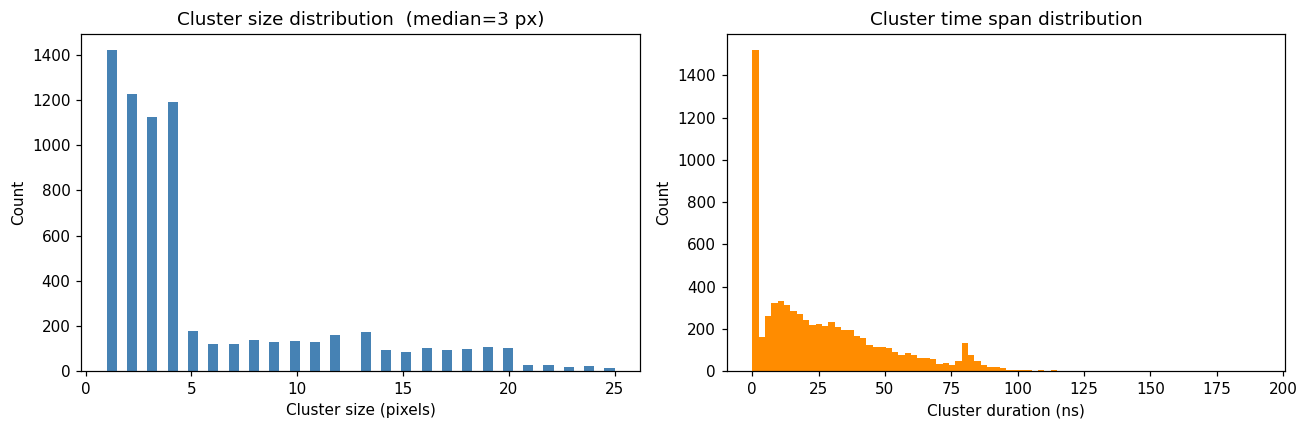

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# cluster size distribution
sizes = clusters_df["n_pixels"]
axes[0].hist(sizes.clip(upper=50), bins=50, color="steelblue")
axes[0].set_xlabel("Cluster size (pixels)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Cluster size distribution  (median={sizes.median():.0f} px)")

# cluster duration
durations = (clusters_df["t_max"] - clusters_df["t_min"]).clip(upper=3000)
axes[1].hist(durations, bins=80, color="darkorange")
axes[1].set_xlabel("Cluster duration (ns)")
axes[1].set_ylabel("Count")
axes[1].set_title("Cluster time span distribution")

plt.tight_layout()

### Parameter sensitivity sweep
Shows how cluster count and size change with different Δt and connectivity settings.
Run this cell to explore — it takes a few seconds.

In [10]:
from tpx3pipe.clustering import sweep

sweep_summary = sweep(
    pixel_df,
    dt_values     = [200, 500, 1000, 2000],
    max_gap_values= [0, 1],
    plots_dir     = plots_dir,
)
sweep_summary

,dt_ns,max_gap,n_clusters,mean_size,median_size,p95_size
0,200,0,7040,5.386506,3.0,18.0
1,200,1,6566,5.775358,3.0,19.0
2,500,0,7040,5.386506,3.0,18.0
3,500,1,6566,5.775358,3.0,19.0
4,1000,0,7040,5.386506,3.0,18.0
5,1000,1,6566,5.775358,3.0,19.0
6,2000,0,7040,5.386506,3.0,18.0
7,2000,1,6566,5.775358,3.0,19.0


## Stage C — Cluster Feature Extraction

Computes per-cluster scalar features used by the GBT classifier (Stage H) and as
auxiliary inputs to the CNN (Stage I):

- **Morphology**: `n_pixels`, bounding box, eccentricity, linearity, compactness  
- **Energy**: `tot_sum`, `tot_max`, `tot_mean`  
- **Timing**: `t_min`, `t_argmax_tot`, `dt_min_vs_argmax` (time-walk indicator)

In [11]:
from tpx3pipe.features import compute_features, plot_feature_diagnostics

feat_df = compute_features(cluster_pixels_df)

# merge into clusters (drop overlapping columns first)
overlap = set(clusters_df.columns) & set(feat_df.columns) - {"cluster_id"}
clusters_df = clusters_df.drop(columns=list(overlap))
clusters_df = clusters_df.merge(feat_df, on="cluster_id", how="left")

print("Feature columns:", [c for c in feat_df.columns if c != "cluster_id"])
feat_df.describe().T[["mean","std","min","max"]]

Feature columns: ['n_pixels', 'tot_sum', 'tot_max', 'tot_mean', 'cx_w', 'cy_w', 'bbox_w', 'bbox_h', 'eccentricity', 'linearity', 'compactness', 't_min', 't_argmax_tot', 'dt_min_vs_argmax']


,mean,std,min,max
cluster_id,3.519500e+03,2.032417e+03,0.000000,7.039000e+03
n_pixels,5.386506e+00,5.434722e+00,1.000000,2.500000e+01
tot_sum,1.395813e+03,2.129358e+03,1.000000,9.703000e+03
tot_max,2.586460e+02,2.623263e+02,1.000000,1.039000e+03
tot_mean,1.738320e+02,1.453993e+02,1.000000,8.210000e+02
cx_w,1.275530e+02,7.121188e+01,2.318252,2.520000e+02
cy_w,1.262951e+02,7.083375e+01,2.178261,2.512736e+02
bbox_w,2.774716e+00,1.723652e+00,1.000000,1.500000e+01
bbox_h,2.756676e+00,1.699309e+00,1.000000,1.300000e+01
eccentricity,6.536411e-01,3.694813e-01,0.000000,1.000000e+00


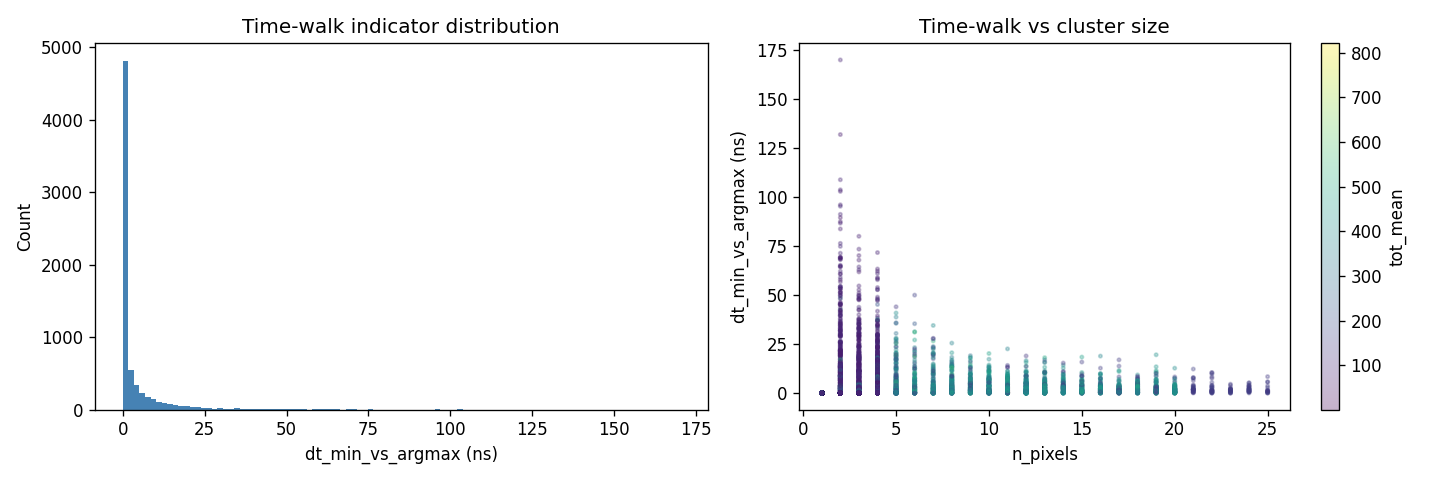

In [12]:
plot_feature_diagnostics(feat_df, plots_dir)
Image(plots_dir / "feature_timewalk.png")

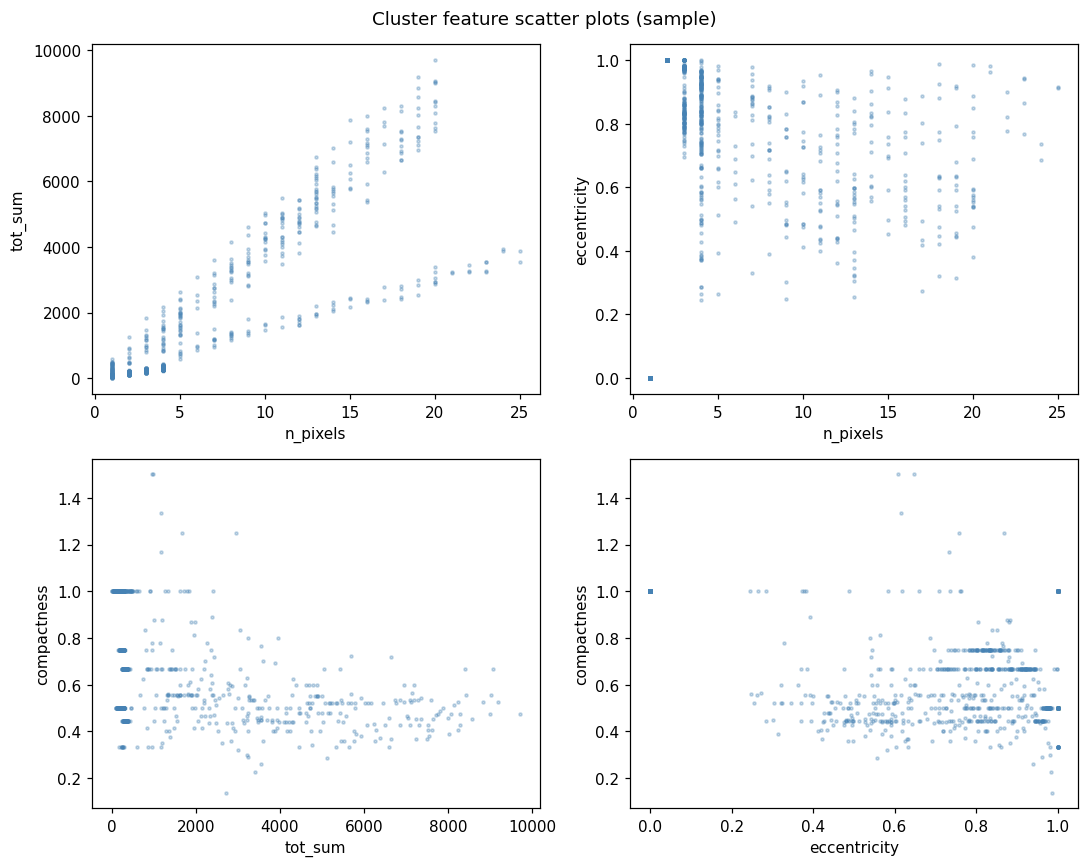

In [13]:
# Pairplot of key morphology features (sample 1000 for speed)
sample = feat_df[["n_pixels","tot_sum","eccentricity","compactness"]].sample(
    min(1000, len(feat_df)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
pairs = [("n_pixels","tot_sum"),("n_pixels","eccentricity"),
         ("tot_sum","compactness"),("eccentricity","compactness")]
for ax, (x, y) in zip(axes.flat, pairs):
    ax.scatter(sample[x], sample[y], s=4, alpha=0.3, color="steelblue")
    ax.set_xlabel(x); ax.set_ylabel(y)
plt.suptitle("Cluster feature scatter plots (sample)")
plt.tight_layout()

## Stage D — Time-of-Flight Computation and Folding

For each cluster:
1. **Raw ToF** = cluster time − most recent TDC edge ≤ cluster time (via `searchsorted`)
2. **Folded ToF** = raw ToF mod measured_period

The fraction of clusters where raw ≠ folded is a direct measure of missed-edge impact.
We also show the **ToF × ToT bivariate histogram** — periodicity structure here can
hint at species separation even before any fitting.

In [14]:
from tpx3pipe.tof import compute_tof, plot_tof_diagnostics

mode = cfg["tof"]["cluster_time_mode"]
clusters_df = compute_tof(clusters_df, tdc_df, period_ns, cluster_time_mode=mode)

valid = clusters_df["folded_tof_ns"].notna()
print(f"Valid clusters with ToF : {valid.sum():,}  "
      f"({100*valid.mean():.1f}%)")
print(f"raw == folded (no wrap) : "
      f"{(clusters_df.loc[valid,'raw_tof_ns'] == clusters_df.loc[valid,'folded_tof_ns']).sum():,}")

Valid clusters with ToF : 7,040  (100.0%)
raw == folded (no wrap) : 7,031


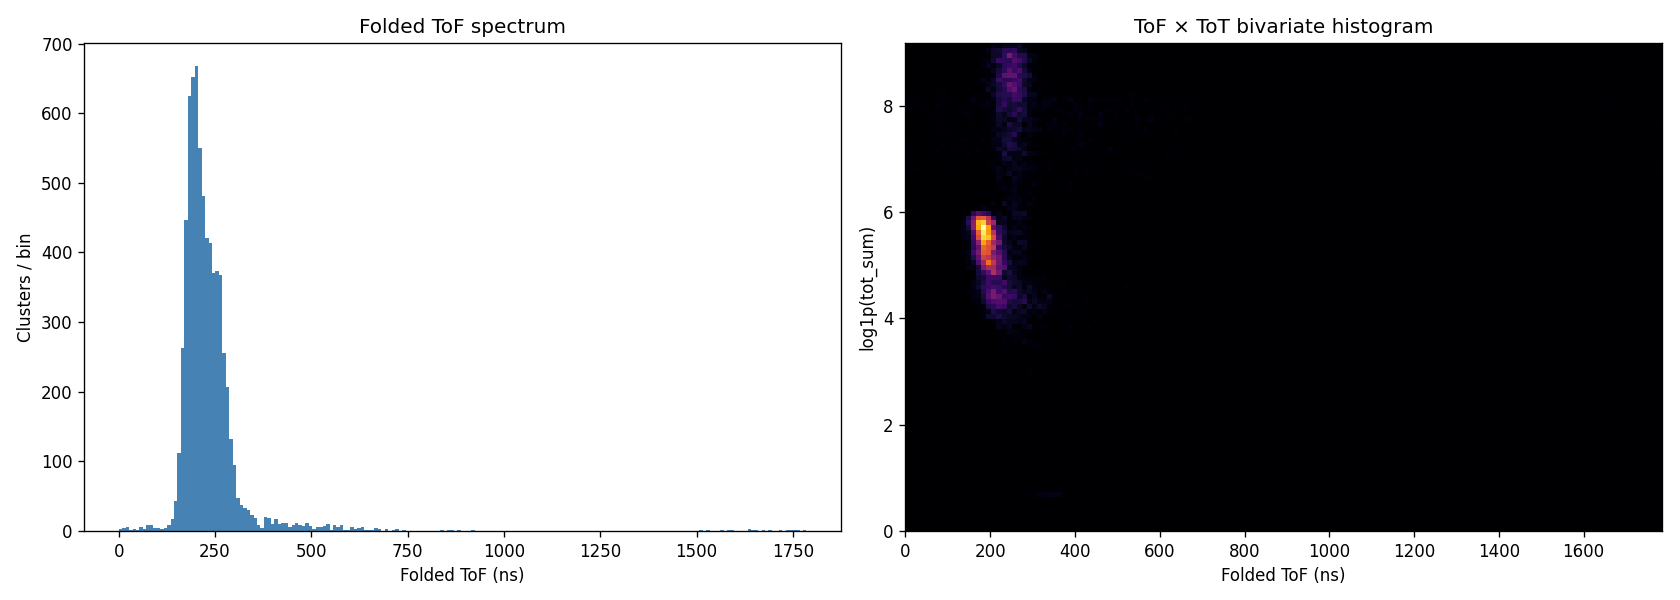

In [15]:
plot_tof_diagnostics(clusters_df, period_ns, plots_dir)
Image(plots_dir / "tof_spectrum.png")

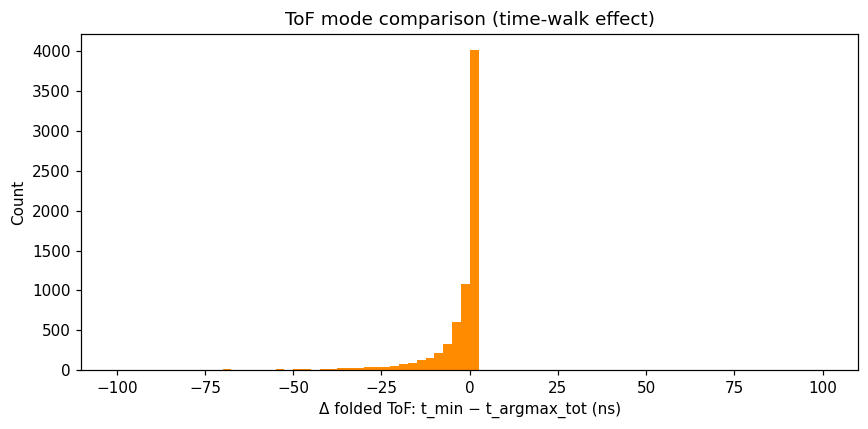

In [16]:
# Compare t_min vs t_argmax_tot based ToF if both columns available
if "t_argmax_tot" in clusters_df.columns:
    alt_mode = "t_argmax_tot" if mode == "t_min" else "t_min"
    alt = compute_tof(clusters_df, tdc_df, period_ns, cluster_time_mode=alt_mode)

    diff = (clusters_df["folded_tof_ns"] - alt["folded_tof_ns"]).dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(diff.clip(-100, 100), bins=80, color="darkorange")
    ax.set_xlabel(f"Δ folded ToF: {mode} − {alt_mode} (ns)")
    ax.set_ylabel("Count")
    ax.set_title("ToF mode comparison (time-walk effect)")
    plt.tight_layout()
else:
    print("t_argmax_tot not available — run features stage first")

## Stage F — Labeling via Mixture Fit

Fits **K Gaussians + 1 uniform background** component to the folded-ToF spectrum
using a custom EM algorithm.

- **K Gaussian peaks** correspond to populations at distinct ToFs (e.g. gamma flash, neutrons)
- **Uniform background** models wrapped slow particles from earlier pulses — the contamination

Each cluster gets a **posterior probability vector** (soft labels) and a **hard label**
(argmax posterior). Clusters below `confidence_threshold` are marked *ambiguous*
and excluded from classifier training.

In [17]:
from tpx3pipe.labeling import label_clusters, plot_labeling_diagnostics

clusters_df, mixture_model = label_clusters(clusters_df, period_ns, cfg)

lcfg = cfg["labeling"]
print(f"Components : {mixture_model.n_components}  "
      f"({mixture_model.n_peaks} peaks + 1 background)")
print(f"Weights    : {np.round(mixture_model.weights_, 3)}")
print(f"Peak means : {np.round(mixture_model.means_, 1)} ns")
print(f"Peak stds  : {np.round(mixture_model.stds_, 1)} ns")
print()

valid = clusters_df["hard_label"].notna()
label_counts = clusters_df.loc[valid, "hard_label"].value_counts().sort_index()
label_names  = mixture_model.component_names() + ["ambiguous"]
for lbl, n in label_counts.items():
    name = label_names[int(lbl)] if int(lbl) >= 0 else "ambiguous"
    print(f"  label {int(lbl):2d} ({name:15s}): {n:5d}  ({100*n/len(clusters_df):.1f}%)")

Components : 3  (2 peaks + 1 background)
Weights    : [0.335 0.611 0.054]
Peak means : [190.4 238.4] ns
Peak stds  : [16.6 39.4] ns

  label -1 (ambiguous      ):  4154  (59.0%)
  label  1 (peak_1         ):  2601  (36.9%)
  label  2 (background     ):   285  (4.0%)


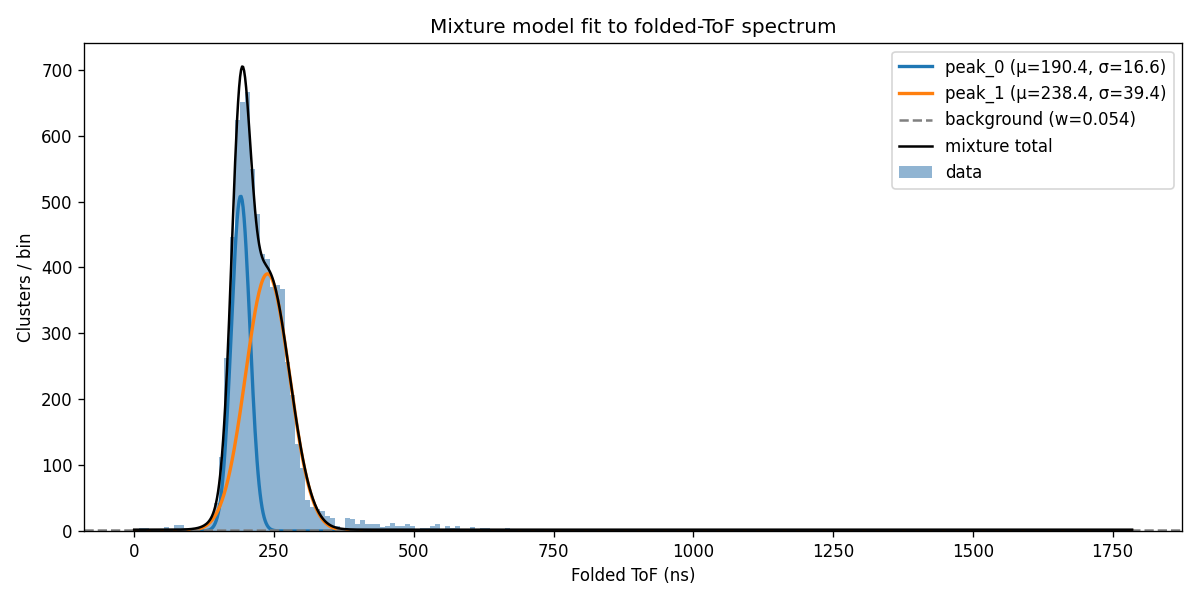

In [18]:
plot_labeling_diagnostics(clusters_df, mixture_model, period_ns, plots_dir)
Image(plots_dir / "labeling_fit.png")

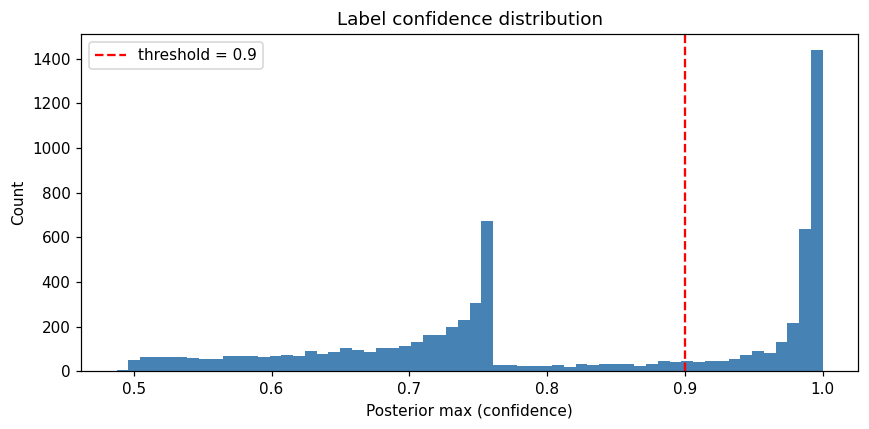

In [19]:
# Confidence distribution
fig, ax = plt.subplots(figsize=(8, 4))
conf = clusters_df["label_confidence"].dropna()
ax.hist(conf, bins=60, color="steelblue")
ax.axvline(lcfg["confidence_threshold"], color="red", lw=1.5, linestyle="--",
           label=f'threshold = {lcfg["confidence_threshold"]}')
ax.set_xlabel("Posterior max (confidence)")
ax.set_ylabel("Count")
ax.set_title("Label confidence distribution")
ax.legend()
plt.tight_layout()

### Ground-truth comparison (synthetic data only)
Compares estimated labels to the known species and wrap counts.

In [20]:
if truth_df is not None and len(truth_df) > 0:
    print("True wrap counts (ground truth):")
    print(truth_df["wrap_count"].value_counts().sort_index())
    print()
    print("True species distribution:")
    print(truth_df["species"].value_counts())
    print()
    true_wrapped_rate = (truth_df["wrap_count"] > 0).mean()
    bg_label = mixture_model.n_peaks
    valid_mask = clusters_df["hard_label"].notna() & (clusters_df["hard_label"] >= 0)
    est_bg_rate = (clusters_df.loc[valid_mask, "hard_label"] == bg_label).mean()
    print(f"True wraparound rate   : {true_wrapped_rate:.3f}")
    print(f"Estimated background   : {est_bg_rate:.3f}")
else:
    print("Ground truth not available (real data mode).")

True wrap counts (ground truth):
wrap_count
0    6049
1     518
Name: count, dtype: int64

True species distribution:
species
gamma              4398
neutron_fast       1628
slow_background     541
Name: count, dtype: int64

True wraparound rate   : 0.079
Estimated background   : 0.099


## Stage H — GBT Baseline Classifier

Trains a LightGBM classifier on the Stage C scalar features.

**Time-block splits** — no random event-level shuffling — prevent temporal leakage:
- Train: first 70% by acquisition time
- Val:   next 15%
- Test:  final 15%

This is the performance bar the CNN must beat.

In [21]:
from tpx3pipe.baseline import train_baseline

baseline_scores, gbt_model, clusters_df = train_baseline(
    clusters_df, cfg, out_dir, plots_dir
)

print(f"GBT test accuracy : {baseline_scores['test_accuracy']:.4f}")
print(f"Train / Val / Test: {baseline_scores['n_train']} / "
      f"{baseline_scores['n_val']} / {baseline_scores['n_test']}")

GBT test accuracy : 0.9538
Train / Val / Test: 2020 / 433 / 433


C:\Users\rr006\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\rr006\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


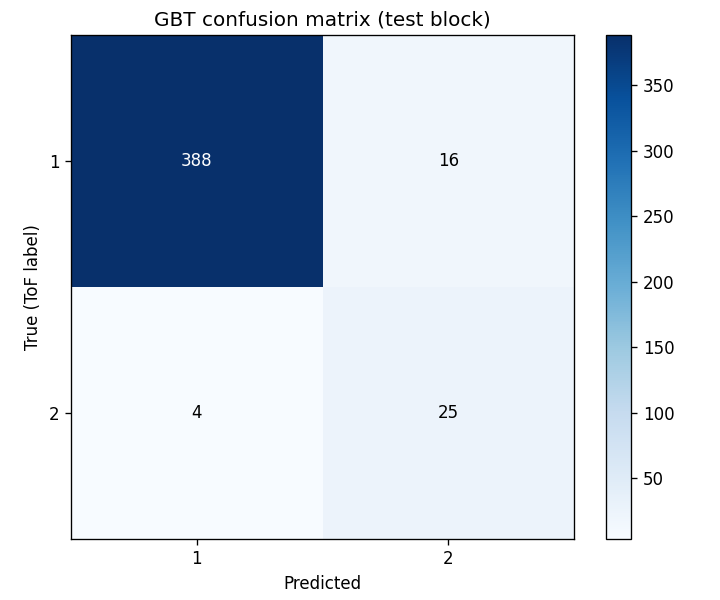

In [22]:
Image(plots_dir / "baseline_confusion.png")

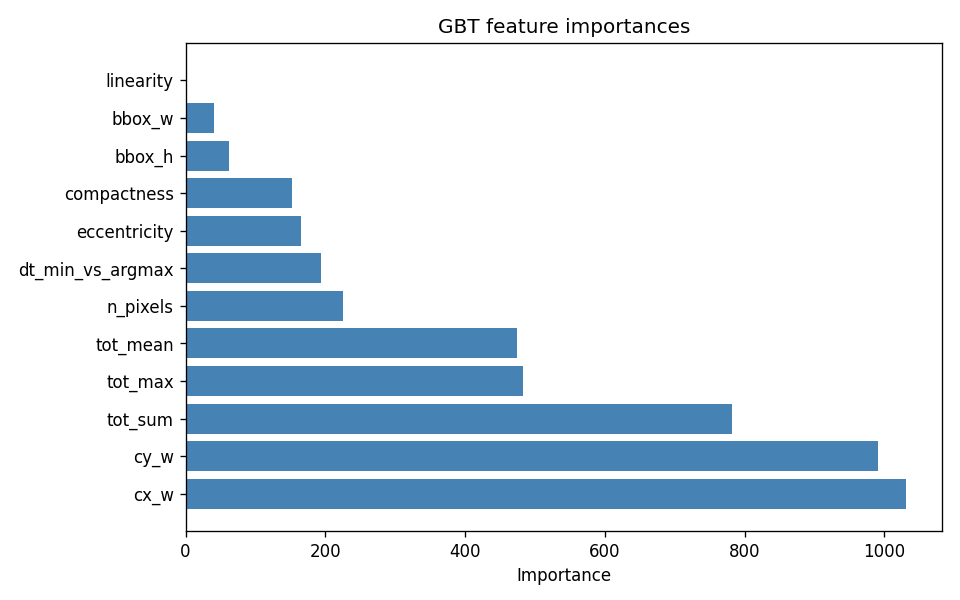

In [23]:
Image(plots_dir / "baseline_importances.png")

In [24]:
# Per-class metrics
report = baseline_scores["classification_report"]
rows = {k: v for k, v in report.items() if isinstance(v, dict)}
pd.DataFrame(rows).T.round(3)

,precision,recall,f1-score,support
1,0.990,0.960,0.975,404.0
2,0.610,0.862,0.714,29.0
macro avg,0.800,0.911,0.845,433.0
weighted avg,0.964,0.954,0.957,433.0


## Stage G — Contamination Diagnostics

Three analyses that quantify how much the ToF labels are contaminated by
slow wrapped particles:

1. **Baseline-under-peak** — uniform background density from the pre-peak region
   → estimated mislabel fraction per class
2. **Morphology bimodality** — GMM check on feature distributions per ToF bin;
   bimodality suggests mixed populations
3. **Confident-disagreement map** — events where the GBT classifier confidently
   predicts a different bin than the ToF label (concentrated disagreement = contamination)

In [25]:
from tpx3pipe.diagnostics import (
    baseline_under_peak, morphology_bimodality,
    confident_disagreement, validate_against_truth, generate_report,
)

bl_result  = baseline_under_peak(clusters_df, period_ns)
bio_result = morphology_bimodality(clusters_df, plots_dir)
dis_ct     = confident_disagreement(clusters_df)

print("=== Baseline-under-peak results ===")
for k, v in bl_result.items():
    print(f"  {k}: {v}")

=== Baseline-under-peak results ===
  background_density_per_ns: 6.960227272727273e-05
  baseline_window_ns: 0.0–100.0
  class_1_mislabel_frac: 0.0076
  class_1_n_events: 2601
  class_2_mislabel_frac: 0.1236
  class_2_n_events: 285


In [26]:
# Bimodality summary
if bio_result:
    print("=== Morphology bimodality ===")
    for cls, feats in bio_result.items():
        flags = [f for f, info in feats.items() if info["bimodal"]]
        print(f"  {cls}: bimodal features = {flags if flags else 'none'}")
else:
    print("No labeled clusters available for bimodality check.")

=== Morphology bimodality ===
  class_1: bimodal features = ['n_pixels', 'tot_sum', 'tot_max', 'eccentricity']
  class_2: bimodal features = ['n_pixels', 'tot_sum', 'tot_max', 'eccentricity']


In [27]:
# Confident-disagreement cross-tab
if dis_ct is not None:
    print("Confident-disagreement map (ToF label vs GBT prediction):")
    print(dis_ct)
else:
    print("No confident disagreements found (or predicted_label column missing).")

Confident-disagreement map (ToF label vs GBT prediction):
predicted_label  1    2
tof_label              
1                0  109
2                8    0


In [28]:
# Validation against ground truth (synth only)
validation = {}
if truth_df is not None and len(truth_df) > 0:
    validation = validate_against_truth(clusters_df, truth_df, bl_result)
    print("=== Contamination estimate vs ground truth ===")
    for k, v in validation.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
else:
    print("Ground truth not available.")

=== Contamination estimate vs ground truth ===
  true_contamination_frac: 0.0789
  estimated_contamination_frac: nan
  error: nan


In [29]:
# Generate the full diagnostics report
generate_report(
    bl_result, bio_result, dis_ct, validation,
    plots_dir, out_dir / "diagnostics_report.md",
)
print(f"Report written to: {out_dir}/diagnostics_report.md")

Report written to: artifacts/diagnostics_report.md


## Stage I — CNN (optional)

Requires PyTorch. Install with:
```
pip install torch --index-url https://download.pytorch.org/whl/cpu
```

The CNN takes **P×P×2 patches** centred on the max-ToT pixel:
- ch0 = `log1p(ToT)`
- ch1 = `time_ns − cluster_t_min` (relative pixel arrival time, clipped at Δt)

No TDC-derived quantities, no absolute time, no chip (x,y) position — leakage-free by design.

In [30]:
try:
    import torch
    from tpx3pipe.cnn.train import train_cnn

    cnn_scores = train_cnn(clusters_df, cluster_pixels_df, cfg, out_dir, plots_dir)

    print(f"CNN test accuracy : {cnn_scores['test_accuracy']:.4f}")
    print(f"GBT test accuracy : {baseline_scores['test_accuracy']:.4f}")
    gbt_acc = baseline_scores['test_accuracy']
    cnn_acc = cnn_scores['test_accuracy']
    if cnn_acc > gbt_acc + 0.01:
        print(f"CNN outperforms GBT by {cnn_acc - gbt_acc:.4f}.")
    else:
        print("CNN does not clearly beat GBT — this is a valid finding.")

except ImportError:
    print("PyTorch not installed. Skipping CNN stage.")
    print("Install: pip install torch --index-url https://download.pytorch.org/whl/cpu")

PyTorch not installed. Skipping CNN stage.
Install: pip install torch --index-url https://download.pytorch.org/whl/cpu


## Summary

All pipeline artifacts land in `artifacts/` and `plots/`.

In [31]:
import json

print("=== Pipeline summary ===")
print(f"  Pixel hits          : {len(pixel_df):,}")
print(f"  TDC edges           : {len(tdc_df):,}")
print(f"  Measured period     : {period_ns:.3f} ns")
print(f"  Clusters found      : {len(clusters_df):,}")
labeled_mask = clusters_df["hard_label"].notna() & (clusters_df["hard_label"] >= 0)
print(f"  Labeled (confident) : {labeled_mask.sum():,}  "
      f"({100*labeled_mask.mean():.1f}%)")
print(f"  GBT test accuracy   : {baseline_scores['test_accuracy']:.4f}")
print()
print("Artifacts:")
for f in sorted(out_dir.iterdir()):
    print(f"  {f.name}")
print()
print("Plots:")
for f in sorted(plots_dir.iterdir()):
    print(f"  {f.name}")

=== Pipeline summary ===
  Pixel hits          : 37,921
  TDC edges           : 54,916
  Measured period     : 1785.009 ns
  Clusters found      : 7,040
  Labeled (confident) : 2,886  (41.0%)
  GBT test accuracy   : 0.9538

Artifacts:
  baseline_scores.json
  cluster_pixels.parquet
  clusters.parquet
  diagnostics_report.md
  results_report.md
  tdc_report.json

Plots:
  baseline_confusion.png
  baseline_importances.png
  clustering_sweep.png
  feature_timewalk.png
  labeling_fit.png
  morphology_class_1.png
  morphology_class_2.png
  tdc_diagnostics.png
  tof_spectrum.png


## Open Questions for SMEs

- **Flight path and trigger offset**: needed to convert ToF → species — currently unknown.
- **Source pulse structure and expected species**: not provided.
- **Energy calibration**: raw ToT only; no per-pixel calibration available.
- **Time-walk correction**: uncorrected; `dt_min_vs_argmax` diagnostic provided above.
- **Expected maximum ToF**: determines whether the 1× period fold is sufficient.

---
See [`REAL_DATA.md`](REAL_DATA.md) for the exact config changes needed when real data arrives.